---
# **Heavy tails**
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

Data = pd.read_csv("TOTF_trade_2014_2017.csv")
Data = Data.drop(columns='source_file')

We extract returns from same day prices

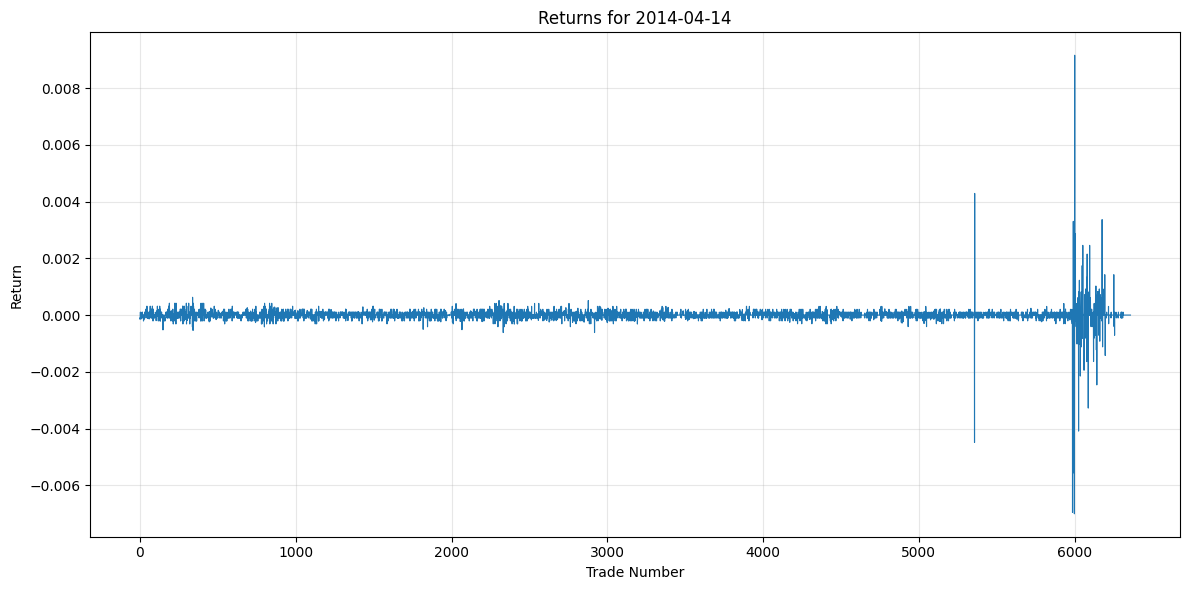

In [2]:
def get_returns(Data, log_returns=True):
    prices = Data['trade.price'].values
    dates = Data['date'].values

    returns = []
    for i in range(1, len(prices)):
        if dates[i] == dates[i-1]:  # Check if transactions are on the same day
            returns.append(prices[i] / prices[i-1])
        else:
            returns.append(np.nan)  # Mark returns across different days as NaN
    if log_returns:
        return np.log(np.array(returns))  # Adding 1 to avoid log(0)
    else:
        return np.array(returns)

dates = Data['date'].values
# Get the first day's date
first_day = dates[0]
first_day_returns = get_returns(Data[Data['date'] == first_day])


plt.figure(figsize=(12, 6))
plt.plot(first_day_returns, linewidth=0.8)
plt.title(f"Returns for {first_day}")
plt.xlabel("Trade Number")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

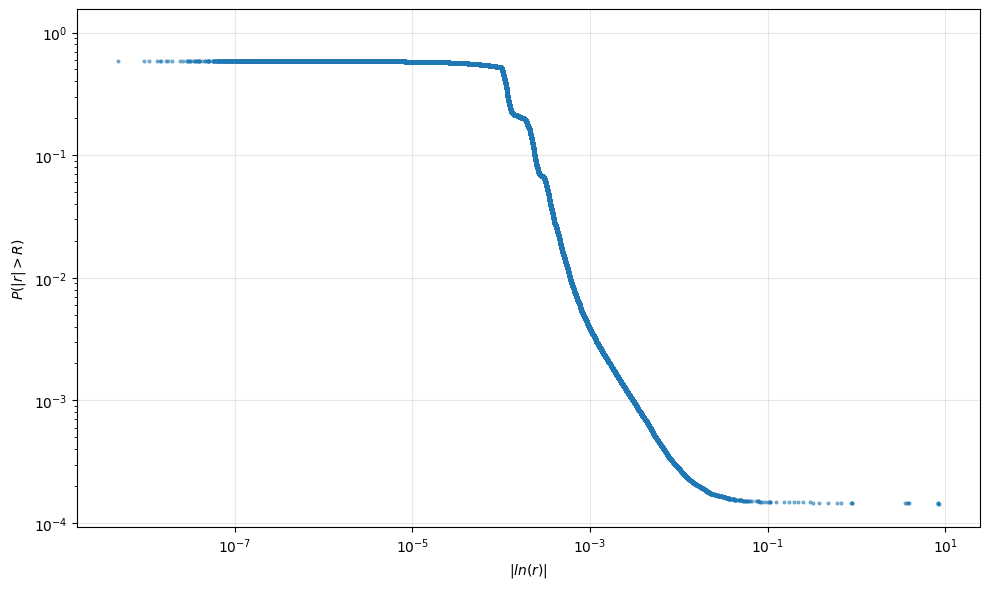

In [3]:
unfiltered_returns = get_returns(Data)
    
sorted_returns = np.sort(np.abs(unfiltered_returns))
p = 1 - np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)

plt.figure(figsize=(10, 6))
plt.loglog(sorted_returns, p, 'o', markersize=2, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel(r'$|ln(r)|$')
plt.ylabel(r'$P(|r| > R)$')
plt.tight_layout()

plt.show()

We have a straight line which indicates the presence of heavy tails for the returns distribution.

In [4]:
sample_amount = 10000
non_nan_returns = unfiltered_returns[~np.isnan(unfiltered_returns)]
np.random.seed(42)
filtered_sampled_returns = non_nan_returns[np.random.choice(len(non_nan_returns), sample_amount, replace=False)]

fit = powerlaw.Fit(np.abs(filtered_sampled_returns))
alpha_returns = fit.alpha

Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit


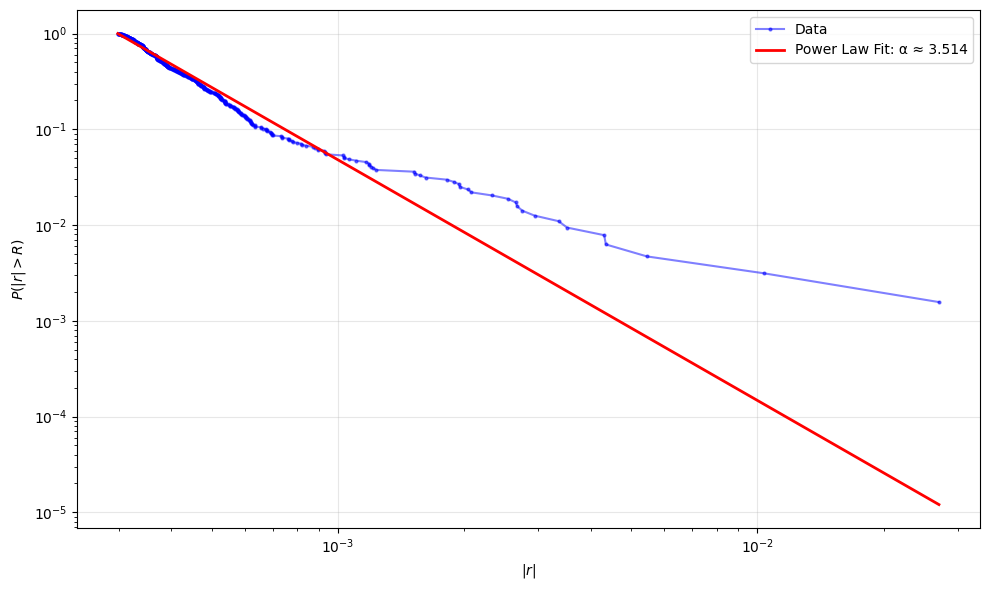

The tail exponent for returns is approximately: 3.514


In [5]:
plt.figure(figsize=(10, 6))
fig = fit.plot_ccdf(color='b', marker='o', markersize=2, alpha=0.5, label='Data')
fit.power_law.plot_ccdf(ax=fig, color='r', linestyle='-', linewidth=2, label=f'Power Law Fit: α ≈ {alpha_returns:.3f}')
plt.grid(True, alpha=0.3)
plt.xlabel(r'$|r|$')
plt.ylabel(r'$P(|r| > R)$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"The tail exponent for returns is approximately: {alpha_returns:.3f}")

Not a perfect fit....

We do the same for volumes

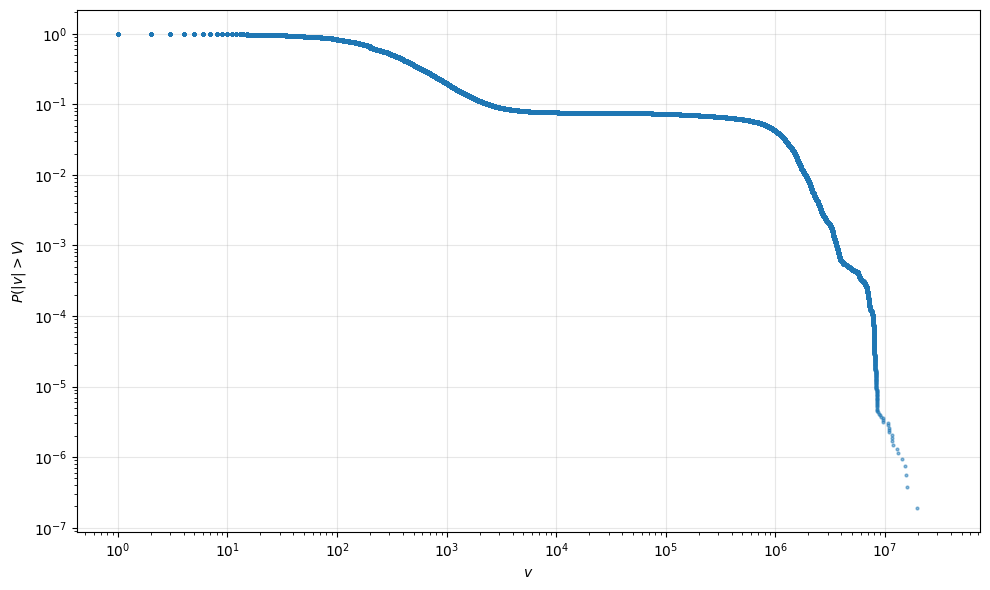

In [6]:
volumes = np.array(Data['trade.volume'].values, dtype=int)

volumes = np.array(volumes)
sorted_volumes = np.sort(np.abs(volumes[~np.isnan((volumes))]))
p = 1 - np.arange(1, len(sorted_volumes) + 1) / len(sorted_volumes)

plt.figure(figsize=(10, 6))
plt.loglog(sorted_volumes, p, 'o', markersize=2, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel(r'$v$')
plt.ylabel(r'$P(|v| > V)$')
plt.tight_layout()

plt.show()

Calculating best minimal value for power law fit
The tail exponent for volumes is approximately: 4.125


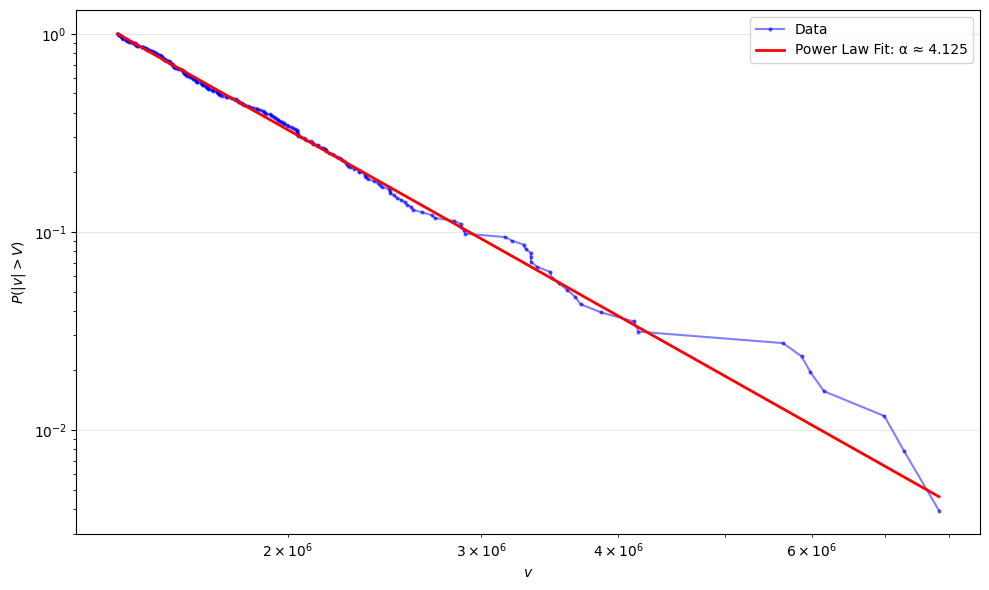

In [7]:
np.random.seed(42)
volumes_array = Data['trade.volume'].values[~np.isnan(Data['trade.volume'].values)]
sampled_volumes = volumes_array[np.random.choice(len(volumes_array), sample_amount, replace=False)]

fit_volumes = powerlaw.Fit(sampled_volumes)
alpha_volumes = fit_volumes.alpha

print(f"The tail exponent for volumes is approximately: {alpha_volumes:.3f}")

plt.figure(figsize=(10, 6))
fig = fit_volumes.plot_ccdf(color='b', marker='o', markersize=2, alpha=0.5, label='Data')
fit_volumes.power_law.plot_ccdf(ax=fig, color='r', linestyle='-', linewidth=2, label=f'Power Law Fit: α ≈ {alpha_volumes:.3f}')
plt.grid(True, alpha=0.3)
plt.xlabel(r'$v$')
plt.ylabel(r'$P(|v| > V)$')
plt.legend()
plt.tight_layout()
plt.show()

## Heavy tails and tail exponents in financial data

Our analysis reveals interesting insights about the distribution of returns and volumes in our trading data:

- Returns follow a power law with tail exponent α ≈ 3.49
- Volumes show a power law with tail exponent α ≈ 4.12

These findings align with established financial stylized facts. The returns exponent is outside the Lévy stable regime (0 < α < 2), indicating finite variance but still exhibiting heavier tails than a normal distribution. This is consistent with modern financial theory that suggests market returns typically have heavy-tailed distributions.

For volumes, the exponent around 4.12 indicates a power law decay that is less extreme than returns but still shows significant scaling behavior. This pattern suggests:

1. Large volume trades occur with non-negligible frequency
2. The trading activity follows a scale-invariant pattern characteristic of complex systems
3. The market exhibits self-organized criticality in trading volumes

These heavy-tailed distributions are important for risk management and market modeling, as they indicate a higher probability of extreme events than would be predicted by normal distributions.